# Practice 15 - CNN 기초 (Convolutional Neural Network)

이미지 데이터를 위한 **합성곱 신경망 (CNN)** 의 기초를 다룹니다. 1D 벡터를 다루던 MLP의 한계를 짚고, 2D 이미지를 그대로 다루는 Conv2d/MaxPool2d 의 동작을 직관적으로 익힌 뒤 MNIST 손글씨 분류 모델을 학습합니다.

| # | 내용 |
|---|------|
| 1 | MLP의 한계 - 이미지를 평탄화하면? |
| 2 | Convolution 연산 직관 |
| 3 | Pooling |
| 4 | CNN 모델 정의 (Class + nn.Module) |
| 5 | MNIST 데이터 파이프라인 |
| 6 | 학습 |
| 7 | MLP vs CNN 비교 |
| 8 | 훈련 결과 시각화 (예측 샘플 + Confusion Matrix) |
| 9 | (보너스) nn.Sequential 로 다시 쓰기 |
| 10 | (도전) 전체 MNIST + 더 많은 epoch — ~99% 도달 |


In [1]:
# Windows + conda 환경에서 torch와 torchvision 동시 로드 시 OpenMP 충돌 회피
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# GPU 자동 선택: CUDA 있으면 GPU, 없으면 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('device:', device)

torch: 2.6.0+cu124
torchvision: 0.21.0+cu124
device: cuda


## GPU 사용 (자동 선택)

지금부터는 **이미지 데이터** 를 다루므로 GPU(NVIDIA CUDA)가 있다면 학습이 훨씬 빨라집니다.

| 데이터 형태 | CPU vs GPU |
|------------|-----------|
| 작은 표 (수십~수백 feature) | CPU가 더 빠름 (전송 오버헤드가 계산보다 큼) |
| **이미지 (28x28~, 채널 포함)** | **GPU가 수십 배 빠름** |

PyTorch는 `device` 객체로 CPU/GPU를 일관되게 다룹니다.

- **로컬 GPU 없음** → 자동으로 CPU 사용 (코드 수정 불필요)
- **Colab GPU 사용** → 메뉴 `런타임 > 런타임 유형 변경 > T4 GPU` 선택

**핵심 규칙 3가지:**
1. 모델 옮기기: `model = CNN().to(device)`
2. 매 배치 옮기기: `X_batch = X_batch.to(device)` (train 함수 안에 포함)
3. 시각화 시 되돌리기: `tensor.cpu().numpy()` 또는 `.detach().cpu()`


---
# 1. MLP의 한계 - 이미지를 평탄화하면?

지금까지 모든 데이터는 **1D 벡터**였습니다.

이미지는 2D 구조를 갖지만, MLP에 넣으려면 **평탄화(flatten)** 가 필요합니다.

> **문제 1:** 평탄화하면 *어떤 픽셀이 어떤 픽셀과 가까운지* 정보가 사라집니다.
>
> **문제 2:** 1픽셀만 옆으로 옮겨도 입력 벡터가 **완전히 달라집니다**.


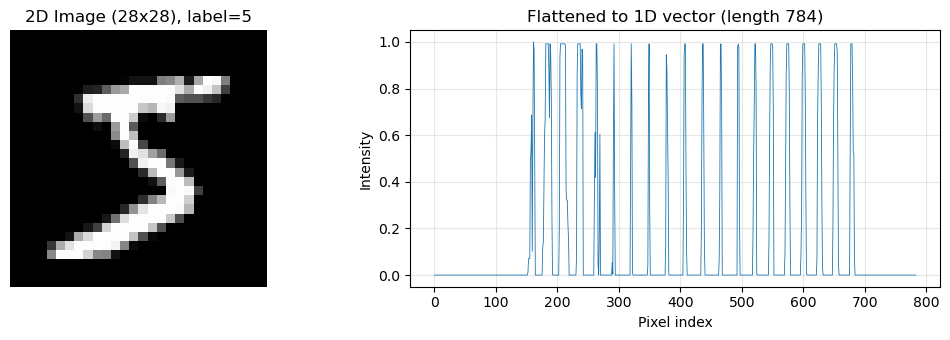

2D shape: (28, 28)  ->  Flattened: (784,)
-> 평탄화하면 인접 픽셀(2D 이웃)이 멀어집니다.


In [2]:
# MNIST 샘플 1장 불러오기 (다운로드는 첫 실행 시에만)
mnist_sample = torchvision.datasets.MNIST(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor())
img, label = mnist_sample[0]   # img: (1, 28, 28), label: int

img_2d = img.squeeze().numpy()         # (28, 28)
img_1d = img_2d.flatten()              # (784,)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].imshow(img_2d, cmap='gray')
axes[0].set_title(f'2D Image (28x28), label={label}')
axes[0].axis('off')
axes[1].plot(img_1d, linewidth=0.6)
axes[1].set_title('Flattened to 1D vector (length 784)')
axes[1].set_xlabel('Pixel index'); axes[1].set_ylabel('Intensity')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'2D shape: {img_2d.shape}  ->  Flattened: {img_1d.shape}')
print('-> 평탄화하면 인접 픽셀(2D 이웃)이 멀어집니다.')


---
# 2. Convolution 연산 직관

**핵심 아이디어:** 작은 필터(커널, 보통 3x3)를 이미지 위에서 슬라이딩하며 같은 가중치로 곱하기-합산.

- 같은 커널이 모든 위치에 적용 → **가중치 공유 (weight sharing)**
- 평탄화 안 함 → **2D 구조 유지**

Input:  (28, 28)
Kernel: (3, 3)


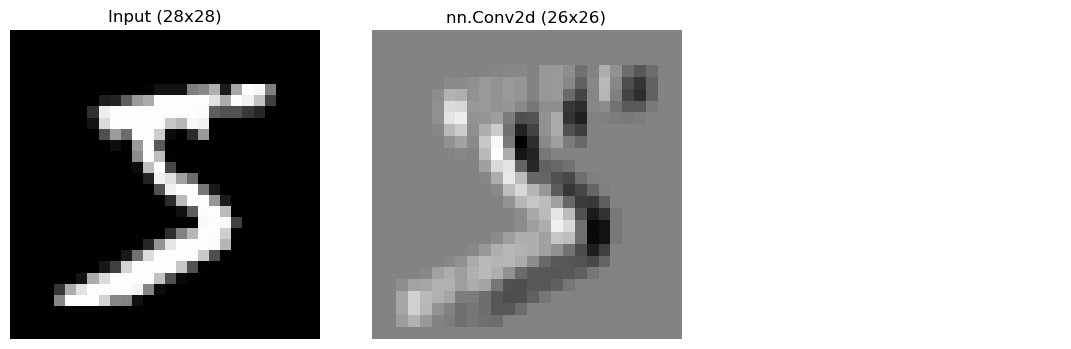

-> 수직 엣지(세로 윤곽)가 강하게 검출됩니다.


In [3]:
# 수동 합성곱: 3x3 수직 엣지 검출 커널
kernel_np = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]], dtype=np.float32)

H, W = img_2d.shape         # 28, 28
out_h, out_w = H - 2, W - 2 # padding=0, stride=1, K=3 -> 26x26

print(f'Input:  {img_2d.shape}')
print(f'Kernel: {kernel_np.shape}')

# nn.Conv2d로 같은 연산 - 결과가 같은지 확인
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)

# 학습 대신 우리가 정의한 커널을 직접 weight에 넣음
with torch.no_grad():
    conv.weight.copy_(torch.tensor(kernel_np).reshape(1, 1, 3, 3))

# nn.Conv2d 입력 shape 규약: (N, C, H, W)
img_4d = torch.tensor(img_2d).unsqueeze(0).unsqueeze(0)   # (1, 1, 28, 28)
out_torch = conv(img_4d).squeeze().detach().numpy()       # (26, 26)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
axes[0].imshow(img_2d, cmap='gray'); axes[0].set_title('Input (28x28)')
axes[1].imshow(out_torch, cmap='gray'); axes[1].set_title('nn.Conv2d (26x26)')
for ax in axes[:2]: ax.axis('off')
axes[2].axis('off')
plt.tight_layout(); plt.show()
print('-> 수직 엣지(세로 윤곽)가 강하게 검출됩니다.')

## 출력 shape 공식

$$H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2P - K}{S} \right\rfloor + 1$$

| 인자 | 의미 |
|------|------|
| $K$ | kernel size |
| $P$ | padding (가장자리 0 추가) |
| $S$ | stride (커널 이동 폭) |

**자주 쓰는 조합:**
- $K=3,\,P=1,\,S=1$ → 출력 크기 **유지** (28→28)
- $K=3,\,P=0,\,S=1$ → 2씩 줄어듦 (28→26)
- $K=2,\,P=0,\,S=2$ (MaxPool) → **절반** (28→14)


In [4]:
# K=3 에서 padding/stride 를 바꿔가며 출력 shape 비교
conv_no_pad = nn.Conv2d(1, 1, kernel_size=3, padding=0, bias=False)
conv_pad    = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv_stride = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=2, bias=False)

x = torch.randn(1, 1, 28, 28)
print(f'Input:                  {tuple(x.shape)}')
print(f'Conv2d(K=3, P=0, S=1):  {tuple(conv_no_pad(x).shape)}   <- 2씩 줄어듦')
print(f'Conv2d(K=3, P=1, S=1):  {tuple(conv_pad(x).shape)}   <- 유지')
print(f'Conv2d(K=3, P=1, S=2):  {tuple(conv_stride(x).shape)}   <- 절반 (stride=2)')

Input:                  (1, 1, 28, 28)
Conv2d(K=3, P=0, S=1):  (1, 1, 26, 26)   <- 2씩 줄어듦
Conv2d(K=3, P=1, S=1):  (1, 1, 28, 28)   <- 유지
Conv2d(K=3, P=1, S=2):  (1, 1, 14, 14)   <- 절반 (stride=2)


---
# 3. Pooling - 다운샘플링

**MaxPool**: 영역 내 **최댓값** (가장 강한 활성)을 골라 해상도를 줄입니다.

- 학습 파라미터 없음
- 작은 위치 변화에 강건
- 연산량 감소


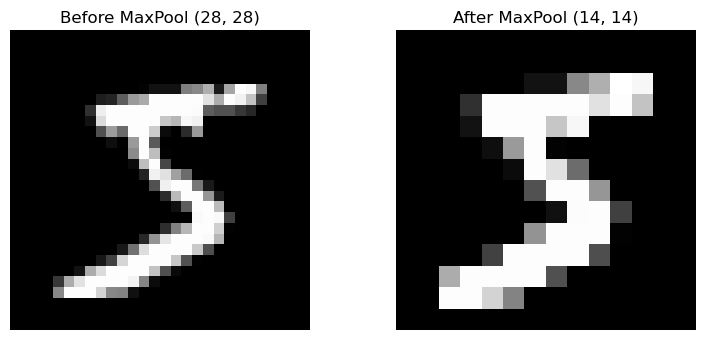

Shape: (1, 1, 28, 28) -> (1, 1, 14, 14)


In [5]:
# MaxPool2d(2): 2x2 영역의 최댓값 -> 해상도 절반
pool = nn.MaxPool2d(kernel_size=2, stride=2)

# Section 2에서 만든 img_4d (1, 1, 28, 28) 재사용
pooled = pool(img_4d).squeeze().numpy()                   # (14, 14)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(img_2d, cmap='gray'); axes[0].set_title(f'Before MaxPool {img_2d.shape}')
axes[1].imshow(pooled, cmap='gray'); axes[1].set_title(f'After MaxPool {pooled.shape}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print(f'Shape: {tuple(img_4d.shape)} -> {tuple(pool(img_4d).shape)}')

---
# 4. CNN 모델 정의

**구조:** 두 개의 `[Conv → ReLU → MaxPool]` 블록 + 마지막 FC

```
Input        (N, 1, 28, 28)
  layer1: Conv2d(1->32, k=3, p=1) -> ReLU -> MaxPool(2)   -> (N, 32, 14, 14)
  layer2: Conv2d(32->64, k=3, p=1) -> ReLU -> MaxPool(2)  -> (N, 64,  7,  7)
  flatten                                                  -> (N, 64*7*7)
  fc:     Linear(64*7*7, 10)                              -> (N, 10)
```

`class ... nn.Module` 패턴을 확장해, **블록 단위로 self.layer1, self.layer2** 처럼 분리합니다. forward도 명시적으로 작성합니다.


In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력: (N, 1, 28, 28)
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (N, 32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2)                                # (N, 32, 14, 14)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (N, 64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2)                                # (N, 64,  7,  7)
        )
        self.fc = nn.Linear(64 * 7 * 7, 10)               # (N, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.flatten(1)        # (N, 64*7*7) - 배치 차원 제외하고 평탄화
        x = self.fc(x)
        return x

torch.manual_seed(42)
model = CNN().to(device)        # 모델을 device로 이동
print(model)
print(f'\nModel device: {next(model.parameters()).device}')

CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=3136, out_features=10, bias=True)
)

Model device: cuda:0


In [7]:
# 각 단계의 출력 shape 확인 (임의 입력 1장으로)
# 입력도 모델과 같은 device 에 있어야 함
x = torch.randn(1, 1, 28, 28).to(device)
print(f'Input         : {tuple(x.shape)}')

x = model.layer1(x)
print(f'After layer1  : {tuple(x.shape)}')
x = model.layer2(x)
print(f'After layer2  : {tuple(x.shape)}')
x = x.flatten(1)
print(f'After flatten : {tuple(x.shape)}')
x = model.fc(x)
print(f'Output (logits): {tuple(x.shape)}')

n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {n_params:,}')

Input         : (1, 1, 28, 28)


After layer1  : (1, 32, 14, 14)
After layer2  : (1, 64, 7, 7)
After flatten : (1, 3136)
Output (logits): (1, 10)

Total parameters: 50,186


---
# 5. MNIST 데이터 파이프라인

**MNIST**: 28x28 손글씨 숫자 (0~9) 70,000장. 이미지 분류의 "Hello World".

torchvision 은 `train=True/False` 두 가지 분할만 제공합니다. 본 노트북에서는 그 두 set 을 학습용 `train_set` 과 학습 중 모니터링용 `val_set` 으로 명명해서 사용합니다. (실무에선 train 일부를 별도 val 로 떼고 진짜 test 는 마지막에 1회만 사용하지만, 이 노트북에서는 학생 단순화를 위해 그대로 사용합니다.)

CPU 실행을 빠르게 하기 위해 **부분집합 (train 10000 / val 2000)** 으로 학습합니다. (마지막 도전 섹션에서 전체 데이터로 다시 학습합니다.)

표준화는 MNIST **literature 표준값** (전체 60000장에서 계산된 mean/std) 을 사용합니다.

In [8]:
# MNIST 정규화 literature 표준값 (MNIST train 60000장에서 계산된 값, 잘 알려진 표준)
MNIST_MEAN = 0.1307
MNIST_STD  = 0.3081

# 다운로드만 (transform 없이 받아서 .data 로 직접 접근 — 전체를 RAM 에 올려 학습 속도 ↑)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True,  download=True)
mnist_val   = torchvision.datasets.MNIST(root='./data', train=False, download=True)

# 첫 10000장 (train) / 2000장 (val) 만 사용 - 빠른 학습용
# .data: uint8 (N, 28, 28) -> 채널 차원 (N, 1, 28, 28) + [0,1] float 변환 + 표준화
X_train = (mnist_train.data[:10000].unsqueeze(1).float() / 255.0 - MNIST_MEAN) / MNIST_STD
y_train = mnist_train.targets[:10000]
X_val   = (mnist_val.data[:2000].unsqueeze(1).float() / 255.0 - MNIST_MEAN) / MNIST_STD
y_val   = mnist_val.targets[:2000]

# TensorDataset + DataLoader
train_set = TensorDataset(X_train, y_train)
val_set   = TensorDataset(X_val,   y_val)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

print(f'Train: {len(train_set)} samples (full: {len(mnist_train)})')
print(f'Val  : {len(val_set)} samples (full: {len(mnist_val)})')

X_batch, y_batch = next(iter(train_loader))
print(f'Batch X shape: {tuple(X_batch.shape)}  (N, C, H, W), dtype={X_batch.dtype}')
print(f'Batch y shape: {tuple(y_batch.shape)}')

Train: 10000 samples (full: 60000)
Val  : 2000 samples (full: 10000)
Batch X shape: (128, 1, 28, 28)  (N, C, H, W), dtype=torch.float32
Batch y shape: (128,)


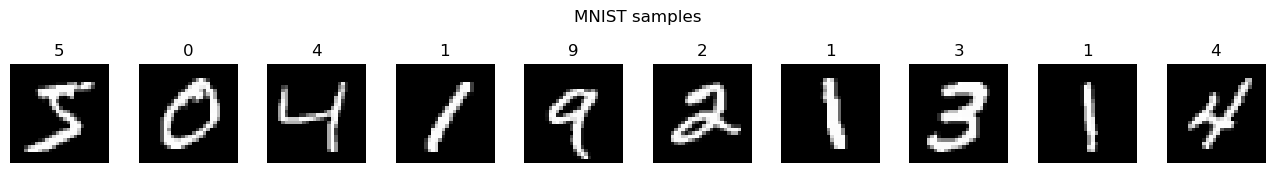

In [9]:
# 샘플 10장 시각화
fig, axes = plt.subplots(1, 10, figsize=(13, 1.6))
for i in range(10):
    img_i, label_i = train_set[i]
    axes[i].imshow(img_i.squeeze(), cmap='gray')
    axes[i].set_title(f'{label_i}')
    axes[i].axis('off')
plt.suptitle('MNIST samples', y=1.05)
plt.tight_layout(); plt.show()

---
# 6. 학습

`train` + `evaluate` 두 함수로 학습 루프를 묶습니다. CNN도 `nn.Module`이므로 학습 루프는 동일합니다.


In [10]:
# 학습 - epochs 만큼 학습 + 매 epoch val 평가
# (train_losses, train_accs, val_losses, val_accs) 반환
def train(model, train_loader, val_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
        train_loss = loss_sum / len(train_loader)
        train_acc = correct / count
        val_loss, val_acc, _ = evaluate(model, val_loader, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f'  Epoch {epoch+1:2d}/{epochs}  '
              f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
              f'train_acc={train_acc:.4f}  val_acc={val_acc:.4f}')
    return train_losses, train_accs, val_losses, val_accs


# 평가 - (loss, accuracy, y_pred) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    preds = []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
            preds.append(output.argmax(1).cpu())
    y_pred = torch.cat(preds).numpy()
    return loss_sum / len(loader), correct / count, y_pred

In [11]:
# CNN 학습
torch.manual_seed(42)
model_cnn = CNN().to(device)
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

print(f'Training CNN on {device}...')
train_losses_cnn, train_accs_cnn, val_losses_cnn, val_accs_cnn = train(model_cnn, train_loader, val_loader, optimizer_cnn, epochs=3, device=device)
print()
print(f'Final val accuracy: {val_accs_cnn[-1]:.4f}')

Training CNN on cuda...


  Epoch  1/3  train_loss=0.8704  val_loss=0.3870  train_acc=0.7559  val_acc=0.8810
  Epoch  2/3  train_loss=0.2473  val_loss=0.2349  train_acc=0.9263  val_acc=0.9295


  Epoch  3/3  train_loss=0.1568  val_loss=0.1680  train_acc=0.9550  val_acc=0.9495

Final val accuracy: 0.9495


---
# 7. 비교 실험: MLP vs CNN

같은 데이터에 두 모델을 학습시켜 봅니다.

- **MLP**: 입력을 평탄화 (784) → Linear → ReLU → Linear → ReLU → Linear (10)
- **CNN**: 위에서 정의한 2-layer CNN

공정한 비교를 위해 **같은 옵티마이저(Adam, lr=1e-3), 같은 epoch**, `torch.manual_seed(42)` 재설정 후 학습합니다.


In [12]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력: (N, 1, 28, 28) -> flatten -> (N, 784)
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)   # (N, 784)
        x = self.fc(x)        # (N, 10)
        return x

torch.manual_seed(42)
model_mlp = MLP().to(device)
print(model_mlp)
print(f'\nMLP parameters: {sum(p.numel() for p in model_mlp.parameters()):,}')
print(f'CNN parameters: {sum(p.numel() for p in model_cnn.parameters()):,}')

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

MLP parameters: 109,386
CNN parameters: 50,186


In [13]:
# MLP 학습 (CNN과 동일한 조건)
torch.manual_seed(42)
model_mlp = MLP().to(device)
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)

print(f'Training MLP on {device}...')
train_losses_mlp, train_accs_mlp, val_losses_mlp, val_accs_mlp = train(model_mlp, train_loader, val_loader, optimizer_mlp, epochs=3, device=device)
print()
print(f'Final val accuracy: {val_accs_mlp[-1]:.4f}')

Training MLP on cuda...
  Epoch  1/3  train_loss=1.0248  val_loss=0.5161  train_acc=0.7448  val_acc=0.8525


  Epoch  2/3  train_loss=0.3549  val_loss=0.4051  train_acc=0.9016  val_acc=0.8790
  Epoch  3/3  train_loss=0.2907  val_loss=0.3767  train_acc=0.9165  val_acc=0.8920

Final val accuracy: 0.8920


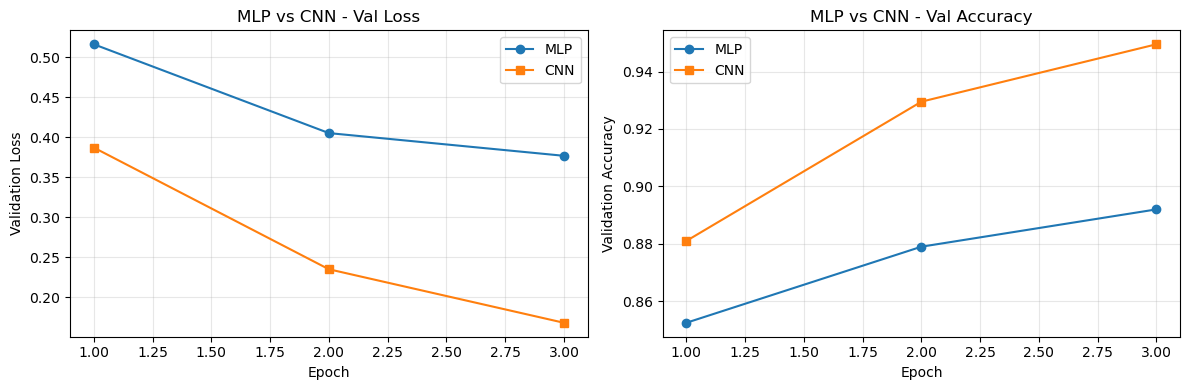

MLP final accuracy: 0.8920
CNN final accuracy: 0.9495


In [14]:
# 비교 그래프 - Validation 만
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(val_losses_mlp) + 1)

axes[0].plot(epochs_range, val_losses_mlp, 'o-', label='MLP')
axes[0].plot(epochs_range, val_losses_cnn, 's-', label='CNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('MLP vs CNN - Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_accs_mlp, 'o-', label='MLP')
axes[1].plot(epochs_range, val_accs_cnn, 's-', label='CNN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('MLP vs CNN - Val Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'MLP final accuracy: {val_accs_mlp[-1]:.4f}')
print(f'CNN final accuracy: {val_accs_cnn[-1]:.4f}')

## 정리

| 구분 | MLP | CNN |
|------|-----|-----|
| 입력 처리 | 평탄화 (784,) | 2D 그대로 (1, 28, 28) |
| 가중치 공유 | 없음 (모든 위치 독립) | **있음** (같은 커널이 슬라이딩) |
| 위치 변화 | 약함 | 강건함 |
| 파라미터 수 | 적당히 큼 | (FC 뺀 conv 부분은) 적음 |
| 같은 epoch | 보통 | **더 좋음** |

CNN이 이미지에 강한 이유는 **2D 구조 보존**과 **가중치 공유** 두 가지입니다.


---
# 8. 훈련 결과 시각화 (CNN 모델)

CNN 모델로 val set 전체 예측을 한 번 더 수집한 뒤 두 가지로 살펴봅니다.

- **틀린 예측 4 개**: 1 × 4 그리드, 제목 `True:X / Pred:Y` (빨강)
- **Confusion Matrix**: 어떤 숫자가 어떤 숫자로 오인되는지

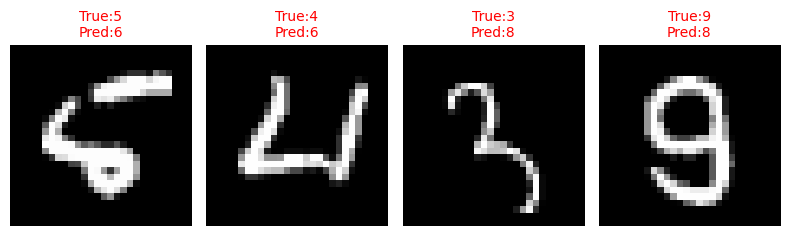

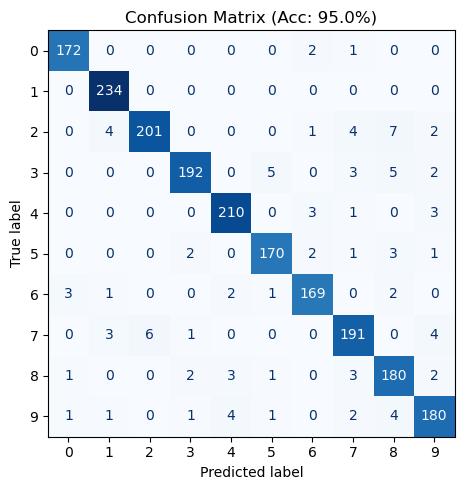

In [15]:
# CNN 예측 수집 (val set)
_, cnn_val_acc, y_pred = evaluate(model_cnn, val_loader, device)
y_val_np = y_val.numpy()

# (1) 틀린 예측 4 개 - 1 x 4 subplot
wrong_idx = np.where(y_pred != y_val_np)[0]
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))
for i in range(min(4, len(wrong_idx))):
    idx = wrong_idx[i]
    axes[i].imshow(X_val[idx, 0].numpy(), cmap='gray')
    axes[i].set_title(f'True:{y_val_np[idx]}\nPred:{y_pred[idx]}', color='red', fontsize=10)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

# (2) Confusion Matrix
cm = confusion_matrix(y_val_np, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix (Acc: {cnn_val_acc:.1%})')
plt.tight_layout(); plt.show()


---
# 9. (보너스) nn.Sequential 로 다시 쓰기

`nn.Sequential` 만으로도 같은 CNN을 정의할 수 있습니다.

**언제 어떤 스타일?**
- `nn.Sequential` 한 줄 정의: 단순 모델, 빠른 프로토타이핑
- `class ... nn.Module`: 블록 분리·forward 커스터마이즈가 필요할 때 (대부분의 실전 모델)

아래 두 정의는 **수학적으로 완전히 동일**합니다.


In [16]:
# 같은 CNN을 nn.Sequential 로 작성
torch.manual_seed(42)
model_seq = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),                  # nn.Module 버전의 .flatten(1) 과 동일
    nn.Linear(64 * 7 * 7, 10)
).to(device)

# class 버전과 출력 shape 비교
torch.manual_seed(42)
model_class = CNN().to(device)

dummy = torch.randn(2, 1, 28, 28).to(device)
out_seq   = model_seq(dummy)
out_class = model_class(dummy)

print(f'Sequential output shape: {tuple(out_seq.shape)}')
print(f'Class       output shape: {tuple(out_class.shape)}')
print(f'Parameter count match: '
      f'{sum(p.numel() for p in model_seq.parameters()) == sum(p.numel() for p in model_class.parameters())}')

Sequential output shape: (2, 10)
Class       output shape: (2, 10)
Parameter count match: True


---
# 10. (도전) 전체 MNIST + 더 많은 epoch - 어디까지 갈 수 있나?

지금까지는 빠른 학습을 위해 **부분집합 (10000장)** 만 사용했습니다.

이번엔 **전체 60000장 + 8 epoch** 으로 학습하면 어디까지 가는지 봅니다.
참고로 레퍼런스 구현(15 epoch, full data, batch=100, lr=0.001)에서는 **약 99% 정확도**가 나옵니다.

> CPU 기준 약 3~5분, GPU(CUDA) 기준 30초 ~ 1분 소요. 시간이 부족하면 이 셀은 건너뛰어도 됩니다.


In [17]:
# 전체 MNIST 데이터 로더 (batch_size 키워서 속도 개선)
train_loader_full = DataLoader(mnist_train, batch_size=256, shuffle=True)
val_loader_full   = DataLoader(mnist_val,   batch_size=512, shuffle=False)

print(f'Train: {len(mnist_train)} samples')
print(f'Val  : {len(mnist_val)} samples')

# 새 CNN 모델 (위와 동일 구조)
torch.manual_seed(42)
model_full = CNN().to(device)
optimizer_full = torch.optim.Adam(model_full.parameters(), lr=1e-3)

import time
print()
print(f'Training on full MNIST (8 epochs) on {device}...')
t0 = time.time()
train_losses_full, train_accs_full, val_losses_full, val_accs_full = train(model_full, train_loader_full, val_loader_full, optimizer_full, epochs=8, device=device)
elapsed = time.time() - t0
print()
print(f'Elapsed: {elapsed:.1f}s on {device}')
print(f'Final val accuracy: {val_accs_full[-1]:.4f}  (peak: {max(val_accs_full):.4f})')

Train: 60000 samples
Val  : 10000 samples

Training on full MNIST (8 epochs) on cuda...


  Epoch  1/8  train_loss=0.3843  val_loss=0.1015  train_acc=0.8912  val_acc=0.9722


  Epoch  2/8  train_loss=0.0828  val_loss=0.0569  train_acc=0.9762  val_acc=0.9831


  Epoch  3/8  train_loss=0.0570  val_loss=0.0475  train_acc=0.9827  val_acc=0.9854


  Epoch  4/8  train_loss=0.0455  val_loss=0.0418  train_acc=0.9862  val_acc=0.9861


  Epoch  5/8  train_loss=0.0390  val_loss=0.0367  train_acc=0.9884  val_acc=0.9880


  Epoch  6/8  train_loss=0.0345  val_loss=0.0356  train_acc=0.9899  val_acc=0.9879


  Epoch  7/8  train_loss=0.0301  val_loss=0.0366  train_acc=0.9911  val_acc=0.9872


  Epoch  8/8  train_loss=0.0267  val_loss=0.0328  train_acc=0.9918  val_acc=0.9891

Elapsed: 30.8s on cuda
Final val accuracy: 0.9891  (peak: 0.9891)


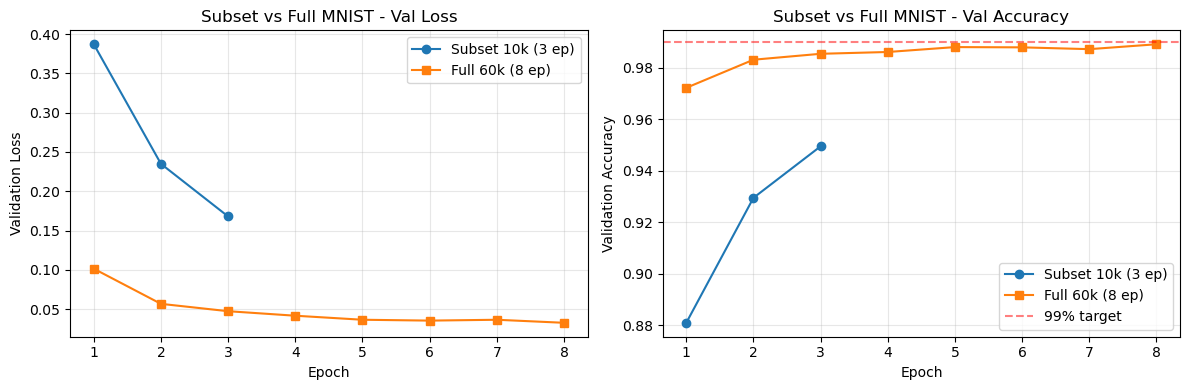

Subset (3 ep) final: 0.9495
Full   (8 ep) final: 0.9891


In [18]:
# 부분집합 vs 전체 데이터 학습 곡선 비교 - Validation 만
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(val_losses_cnn)+1), val_losses_cnn, 'o-', label=f'Subset 10k (3 ep)')
axes[0].plot(range(1, len(val_losses_full)+1), val_losses_full, 's-', label=f'Full 60k (8 ep)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Subset vs Full MNIST - Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(val_accs_cnn)+1), val_accs_cnn, 'o-', label=f'Subset 10k (3 ep)')
axes[1].plot(range(1, len(val_accs_full)+1), val_accs_full, 's-', label=f'Full 60k (8 ep)')
axes[1].axhline(0.99, ls='--', color='red', alpha=0.5, label='99% target')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Subset vs Full MNIST - Val Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Subset (3 ep) final: {val_accs_cnn[-1]:.4f}')
print(f'Full   (8 ep) final: {val_accs_full[-1]:.4f}')

---
### 연습 문제

1. CNN 모델의 `Conv2d(1, 32, ...)` 의 `32`(출력 채널 수)를 16, 64로 바꾸어 학습 결과를 비교해 보세요.
2. `MaxPool2d` 를 `AvgPool2d` 로 바꾸면 정확도가 어떻게 달라질까요?
3. CNN에 한 블록을 더 쌓아 (`Conv → ReLU → MaxPool`) 3-layer CNN으로 확장해 보세요. (Hint: $7 \times 7 \to 3 \times 3$, FC 입력 크기 조정 필요)


In [19]:
# 연습 문제 풀이 공간
